In [ ]:
import sys
sys.path.append('../src')

In [ ]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

In [ ]:
from context import TriangleIntegrandContext
from integrand_builder import IntegrandBuilder

from context import TriangleIntegrandEvaluator
from wrapped_eval import WrappedEvaluator

ctx = TriangleIntegrandContext()

ib_centered = IntegrandBuilder()
ib_centered.use_exp_mask = False
ib_centered.check_singularities_per_sample = False # not necessary for this example, improves performance
ib_centered.center_counterterm_region_at_origin = True
ib_uncentered = IntegrandBuilder()
ib_uncentered.use_exp_mask = False
ib_uncentered.check_singularities_per_sample = False # not necessary for this example, improves performance
ib_uncentered.center_counterterm_region_at_origin = False

centered = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_centered.combined_result(), ib_centered.get_args(), "centered_theta"), ctx
)
uncentered = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_uncentered.combined_result(), ib_uncentered.get_args(), "uncentered_theta"), ctx
)

Compiling evaluator: "centered_theta"
Done!
Compiling evaluator: "uncentered_theta"
Done!


# plot the integrand and threshold subtraction

<Figure size 2000x1000 with 0 Axes>

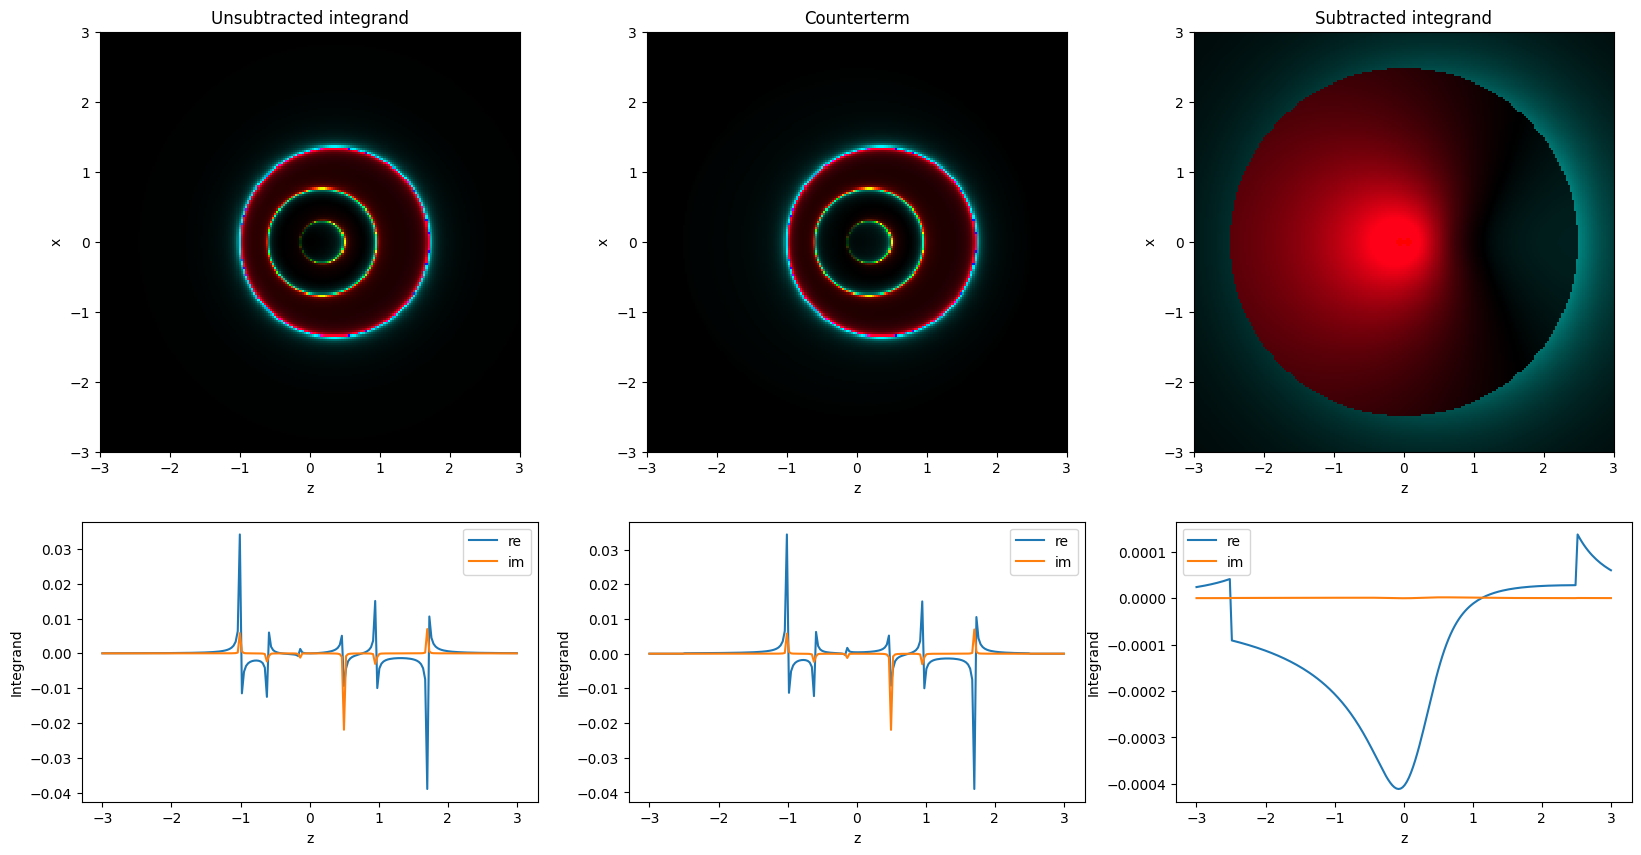

<Figure size 2000x1000 with 0 Axes>

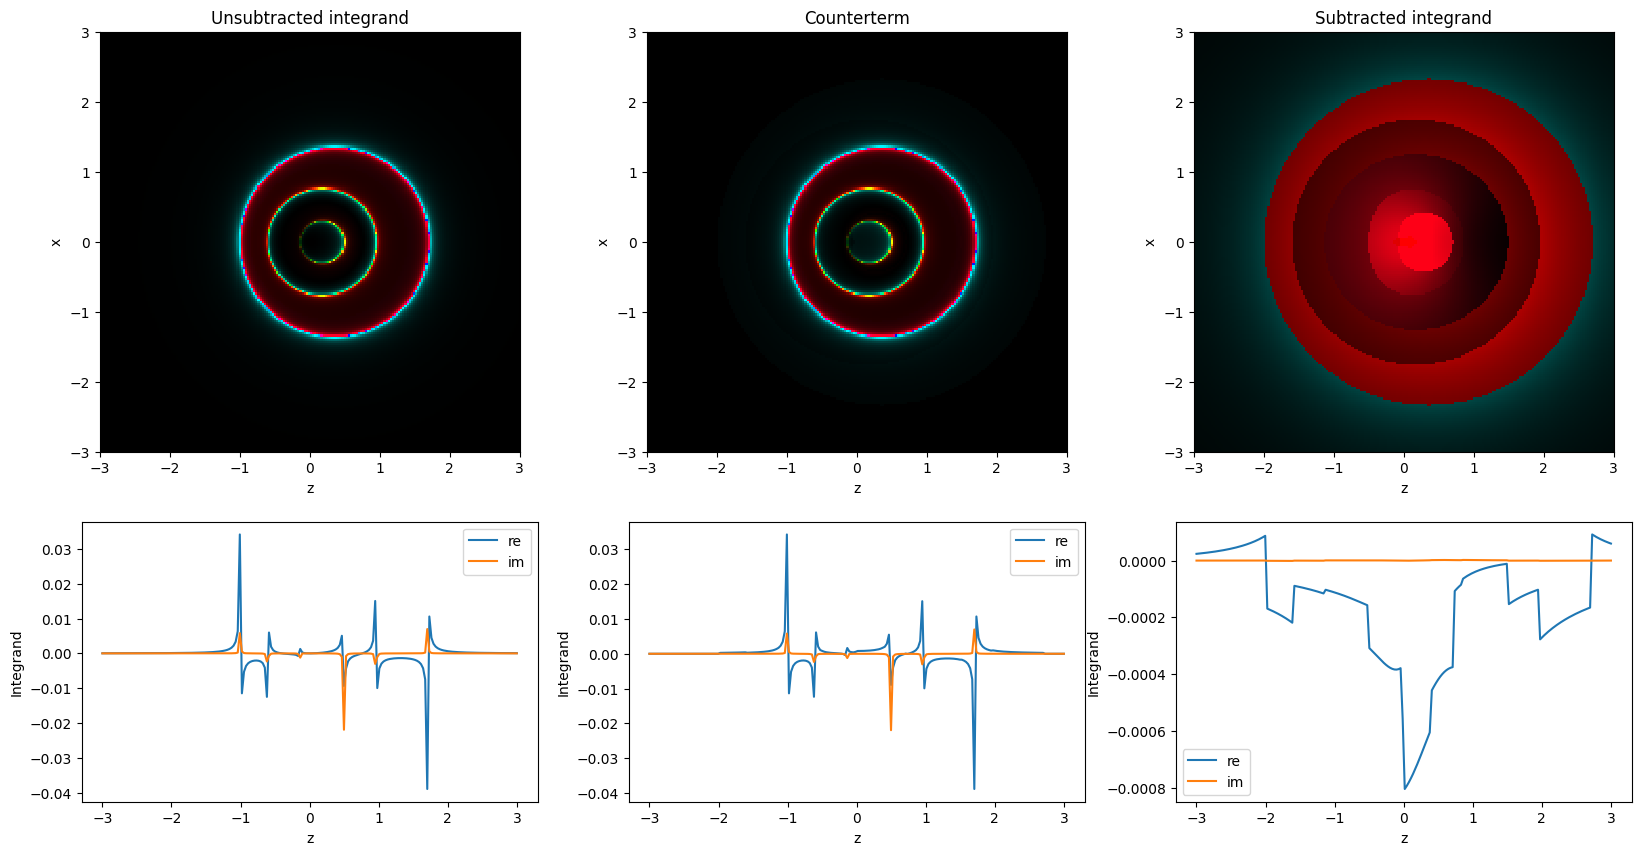

In [ ]:
ctx.set_external_momenta(1, 3, 8)

mass = 0.4*(1-0.01j)
ctx.masses = [mass, mass, mass]

ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
centered.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/centered_subtraction.png", dpi=300)
plt.show()

ctx.subtraction_width = 1
ctx.mask_width = 1
uncentered.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/uncentered_subtraction.png", dpi=300)
plt.show()

In [ ]:
from symbolica import RandomNumberGenerator
rng = RandomNumberGenerator(0,0)

In [ ]:
from context import spherical
from integrator import ComplexIntegrator


def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [ ]:
mass = 0.4
sample_gammas =  0.1*0.0001**np.linspace(0,1,21)
sample_masses = mass * (1-1j*sample_gammas)

ref_gammas = 0.1*0.0001**np.linspace(0,1,50)
ref_masses = mass * (1-1j*ref_gammas)

ctx.combined_integrand()

ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
centered_res = integrate_over_masses(sample_masses, centered)


ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
uncentered_res = integrate_over_masses(sample_masses, uncentered)

ctx.only_unsubtracted()
unsubtracted_res = integrate_over_masses(sample_masses, centered)

ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

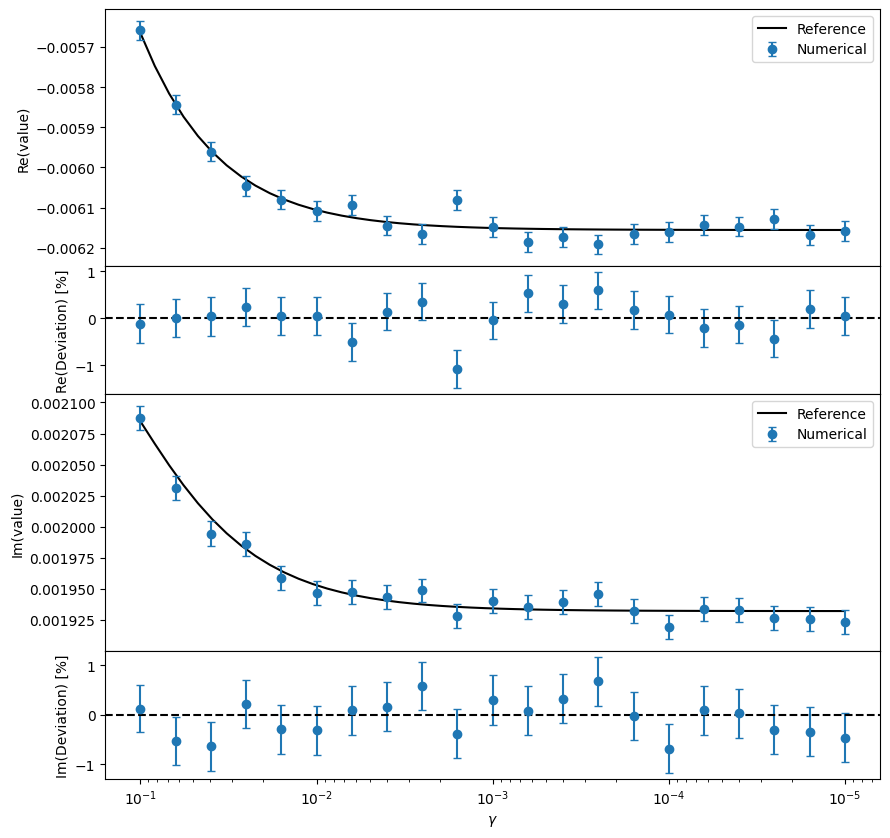

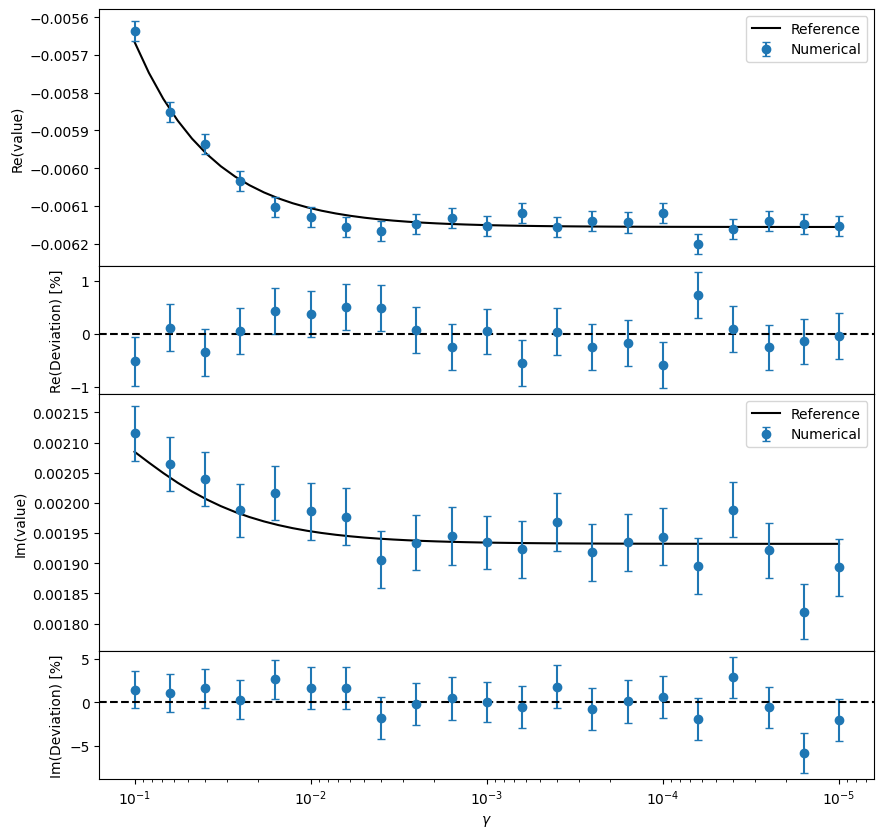

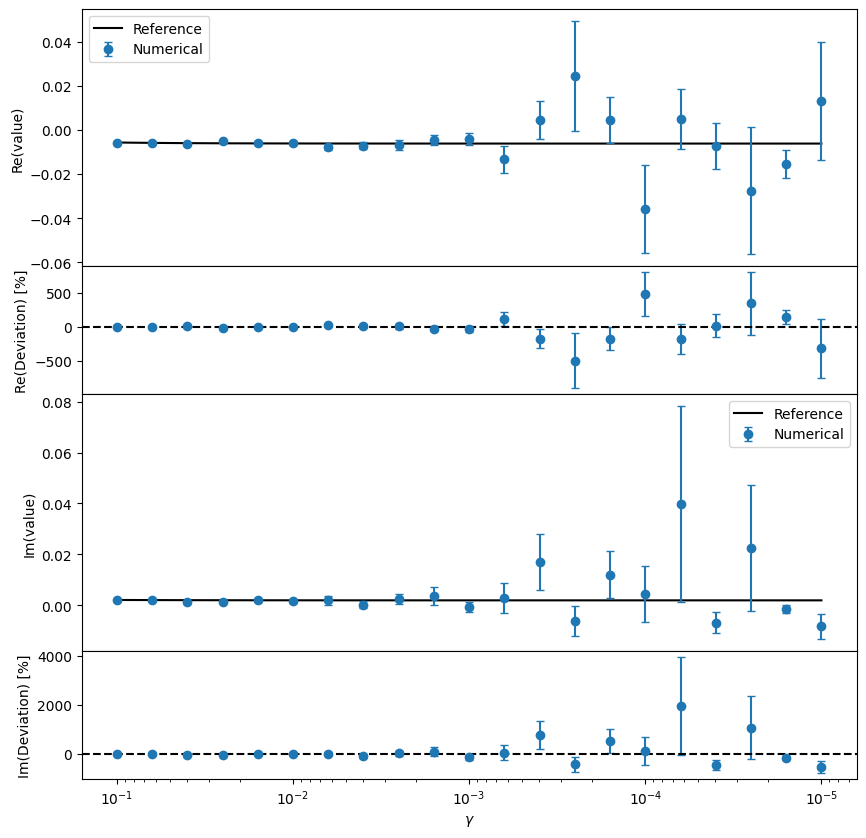

In [ ]:
from plot_util import plot_complex_integration_with_ref

fig = plot_complex_integration_with_ref(
    centered_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.gca().invert_xaxis()
plt.savefig(f"../images/small_width/integration_centered.png", dpi=300)
plt.show()


fig = plot_complex_integration_with_ref(
    uncentered_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.gca().invert_xaxis()
plt.savefig(f"../images/small_width/integration_uncentered.png", dpi=300)
plt.show()


fig = plot_complex_integration_with_ref(
    unsubtracted_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.savefig(f"../images/small_width/integration_unsubtracted.png", dpi=300)
plt.gca().invert_xaxis()
plt.show()

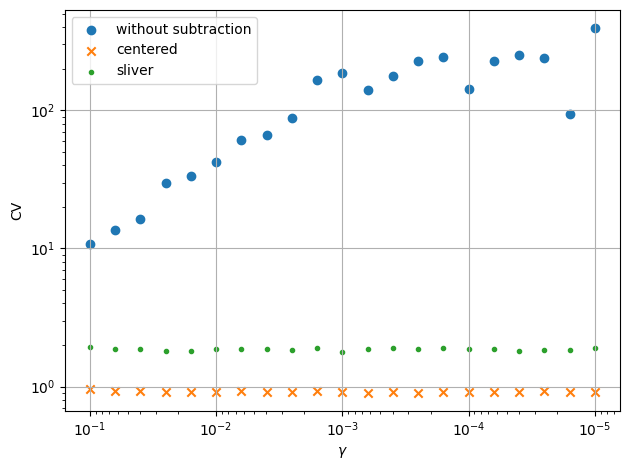

In [ ]:
plt.scatter(sample_gammas, [r.cv() for r in unsubtracted_res], label = 'without subtraction', marker='o')
plt.scatter(sample_gammas, [r.cv() for r in centered_res],  label = 'centered', marker='x')
plt.scatter(sample_gammas, [r.cv() for r in uncentered_res],  label = 'sliver', marker='.')
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('$\\gamma$')
plt.ylabel('CV')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"../images/small_width/cv.png", dpi=300)
plt.show()